<h1>
<center>CFRM 421/521</center>
</h1>

<h1>
<center>Ziwen Chen</center>
</h1>

<h1>
<center>Homework 4</center>
</h1>

* **Due: Tuesday, May 27, 2025, 11:59 PM**


* Total marks: 43


* Late submissions are allowed, but a 20% penalty per day applies. Your last submission is considered for calculating the penalty.


*  Use this Jupyter notebook as a template for your solutions. **Your solution must be submitted as both one Jupyter notebook and one PDF file on Gradescope.** There will be two modules on Gradescope, one for each file type. The notebook must be already run, that is, make sure that you have run all the code, save the notebook, and then when you reopen the notebook, checked that all output appears as expected. You are allowed to use code from the textbook, textbook website, or lecture notes.

# 1. A regression MLP [12 marks]

Consider the original source of the California housing data (used in Homework 2) in Scikit-Learn.  The data is obtained and split using the code below, where we split off 20% as the test set, and then split off 20% of the training set as a validation set, and keep the remaining 80% of the training set as the actual training set. The following code creates the training set `X_train`, `y_train`, the validation set `X_valid`, `y_valid` and the test set `X_test`, `y_test`.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sympy.abc import alpha
from tensorflow.python.keras.saving.saved_model_experimental import sequential

housing = fetch_california_housing ()
X = housing.data
y = housing.target

X_train_tmp, X_test, y_train_tmp, y_test = train_test_split (X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split (X_train_tmp, y_train_tmp, test_size=0.2, random_state=42)

## (a) [4 marks]

Use `tensorflow.keras` to train a regression MLP with a normalization layer as the first layer (`tf.keras.layers.Normalization(input_shape=X_train.shape[1:])`), and one hidden layer of 50 ReLU neurons. For the output layer, try both a ReLU activation function and no activation function (which is equivalent to the identity function). Explain which choice is better. Use the appropriate weight initialization. Use the Nadam optimizer. Train for 30 epochs, and report the mean squared error on the validation set. In the `.compile()` method, use `loss="mse"`.

**[Add your solution here]**

In [2]:
def build_model (output_activation, X):
    norm_layer = tf.keras.layers.Normalization (input_shape=X.shape[1:])
    norm_layer.adapt (X)

    model = tf.keras.Sequential ([
        norm_layer,
        tf.keras.layers.Dense (50, activation='relu', kernel_initializer='he_normal'),
        tf.keras.layers.Dense (1, activation=output_activation)
    ])
    return model


model_relu = build_model ('relu', X_train)
model_linear = build_model (None, X_train)

/Users/ziwenchen/PycharmProjects/LLM/.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [3]:
for name, model in [('ReLU output', model_relu), ('Linear output', model_linear)]:
    model.compile (
        optimizer=tf.keras.optimizers.Nadam (),
        loss='mse',
        metrics=['mse']
    )
    print (f"\n>>> Training model with {name}:")
    model.fit (X_train, y_train,
               validation_data=(X_valid, y_valid),
               epochs=30,
               batch_size=32,
               verbose=1)


>>> Training model with ReLU output:
Epoch 1/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 521us/step - loss: 2.6575 - mse: 2.6575 - val_loss: 0.6348 - val_mse: 0.6348
Epoch 2/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 365us/step - loss: 0.5683 - mse: 0.5683 - val_loss: 0.4672 - val_mse: 0.4672
Epoch 3/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 381us/step - loss: 0.4324 - mse: 0.4324 - val_loss: 0.4206 - val_mse: 0.4206
Epoch 4/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - loss: 0.3975 - mse: 0.3975 - val_loss: 0.4055 - val_mse: 0.4055
Epoch 5/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 367us/step - loss: 0.3779 - mse: 0.3779 - val_loss: 0.3975 - val_mse: 0.3975
Epoch 6/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step - loss: 0.3816 - mse: 0.3816 - val_loss: 0.6448 - val_mse: 0.6448
Epoch 7/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step - loss: 0.3913 - mse: 0.3913 - val_loss: 0.3885 - val_mse: 0.3885
Epoch 8/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 370us/step - loss: 0.3694 - mse: 0.3694 - val_loss: 0.3829 - val_mse: 0.3829
Ep

In [4]:
mse_relu_out = model_relu.evaluate (X_valid, y_valid, verbose=0)[1]
mse_linear_out = model_linear.evaluate (X_valid, y_valid, verbose=0)[1]
print (f"\nValidation MSE — ReLU output:   {mse_relu_out:.4f}")
print (f"Validation MSE — Linear output: {mse_linear_out:.4f}")


Validation MSE — ReLU output:   0.3613
Validation MSE — Linear output: 0.5843


***Apparently, RELU*** is usually better. After few times of trying, Linear activation is really stable, whereas RELU tends to perform better but unstable.

## (b) [6 marks]

Read the section "Fine-Tuning Neural Network Hyperparameters" in the textbook and the corresponding section in the [Jupyter notebook](https://github.com/ageron/handson-ml3/blob/main/10_neural_nets_with_keras.ipynb) on the textbook website using Keras Tuner. You will need to install the package `keras_tuner` if you don't already have it.

Then use Keras Tuner to do a randomized search to search for the best hyperparameters. Do the randomized search over the first 5000 observations of the training set. Use 20 iterations, 20 epochs per iteration. Use the same network architecture as (a) except where otherwise specified below. Use no activation function for the output layer. Use a seed of 42, and the objective is clearly to minimize validation loss. The hyperparameters to search over are:

* Hidden layers: 1 to 5.
* Number of neurons per layer: 1 to 100.
* Learning rate: 1e-4 to 1e-2 using log sampling.
* $\ell_2$ regularizers with `l2` value: 1e-4 to 100 using log sampling.
* Optimizer: `tf.keras.optimizers.SGD(learning_rate=learning_rate,clipnorm=1.0)` and `tf.keras.optimizers.Nadam(learning_rate=learning_rate)`.

Print the best hyperparameter. (You can ignore any warning message you may get).

**[Add your solution here]**

In [5]:
import keras_tuner as kt
import tensorflow as tf


def build_model (hp):
    # 超参数
    n_hidden = hp.Int ("n_hidden", 1, 5, default=2)
    n_neurons = hp.Int ("n_neurons", 1, 100, default=50)
    learning_rate = hp.Float ("learning_rate", 1e-4, 1e-2, sampling="log", default=1e-3)
    l2_strength = hp.Float ("l2_strength", 1e-4, 1e2, sampling="log", default=1e-2)
    opt_name = hp.Choice ("optimizer", ["sgd", "nadam"])

    # 构造优化器
    if opt_name == "sgd":
        optimizer = tf.keras.optimizers.SGD (learning_rate=learning_rate, clipnorm=1.0)
    else:
        optimizer = tf.keras.optimizers.Nadam (learning_rate=learning_rate)

    # 搭模型
    model = tf.keras.Sequential ()
    model.add (tf.keras.layers.Flatten (input_shape=X_train.shape[1:]))
    for _ in range (n_hidden):
        model.add (tf.keras.layers.Dense (
            n_neurons,
            activation="relu",
            kernel_initializer="he_normal",
            kernel_regularizer=tf.keras.regularizers.l2 (l2_strength)
        ))
    model.add (tf.keras.layers.Dense (
        1,
        activation=None,
        kernel_initializer="glorot_uniform",
        kernel_regularizer=tf.keras.regularizers.l2 (l2_strength)
    ))

    model.compile (
        loss="mse",
        optimizer=optimizer,
        metrics=["mse"]
    )
    return model

In [6]:
# init RandomSearch
tuner = kt.RandomSearch (
    hypermodel=build_model,
    objective=kt.Objective ("val_loss", direction="min"),  # 最小化验证集 MSE
    max_trials=20,  # 一共搜索 20 次（iterations）
    seed=42,
    directory="tuner_dir",  # 存储搜索结果的文件夹
    project_name="housing"  # 子目录名字
)

# 开始搜索（只用前 5000 条训练数据，每次跑 20 epochs）
X_train_5k = X_train[:5000]
y_train_5k = y_train[:5000]
tuner.search (
    X_train_5k, y_train_5k,
    validation_data=(X_valid, y_valid),
    epochs=20,
    batch_size=32,
    verbose=1
)


Reloading Tuner from tuner_dir/housing/tuner0.json


In [7]:
# 查看最优超参数
best_hps = tuner.get_best_hyperparameters (num_trials=1)[0]
print ("best hyperparameters: ：")
for key, val in best_hps.values.items ():
    print (f"  {key} = {val}")

best hyperparameters: ：
  n_hidden = 1
  n_neurons = 50
  learning_rate = 0.0029044390072926946
  l2_strength = 0.001575913000039709
  optimizer = nadam


## (c) [2 marks]

For the best model in (b), train the model on the full training data for 200 epochs. Plot the learning curve. Does it look like the model is overfitting?

**[Add your solution here]**

In [8]:
best_model = tuner.get_best_models (num_models=1)[0]
history = best_model.fit (X_train, y_train, validation_data=(X_valid, y_valid), epochs=200, batch_size=32, verbose=1)

Epoch 1/200


/Users/ziwenchen/PycharmProjects/LLM/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/ziwenchen/PycharmProjects/LLM/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 11 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step - loss: 152.3806 - mse: 152.2542 - val_loss: 16.0877 - val_mse: 15.9679
Epoch 2/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step - loss: 150.0728 - mse: 149.9536 - val_loss: 3.5170 - val_mse: 3.3994
Epoch 3/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step - loss: 1.7245 - mse: 1.6073 - val_loss: 3.4659 - val_mse: 3.3499
Epoch 4/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 375us/step - loss: 3.5032 - mse: 3.3874 - val_loss: 4.0138 - val_mse: 3.8990
Epoch 5/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step - loss: 44.6457 - mse: 44.5312 - val_loss: 1.2634 - val_mse: 1.1501
Epoch 6/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step - loss: 62.7104 - mse: 62.5975 - val_loss: 17.6892 - val_mse: 17.5777
Epoch 7/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 375us/step - loss: 123.0933 - mse: 122.9821 - val_loss: 171.0998 - val_mse: 170.9894
Epoch 8/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 384us/step - loss: 30.3233 - mse: 30.2135 - val_loss: 8.0751 - val_mse: 7.9665
Epoch 9/200
413/41

In [9]:
mse = best_model.evaluate (X_test, y_test, verbose=0)[1]
mse

0.6497564315795898

In [10]:
reg_term = tf.add_n (best_model.losses).numpy ()
print ("Sum of all L2 terms:", reg_term)

Sum of all L2 terms: 0.04382774


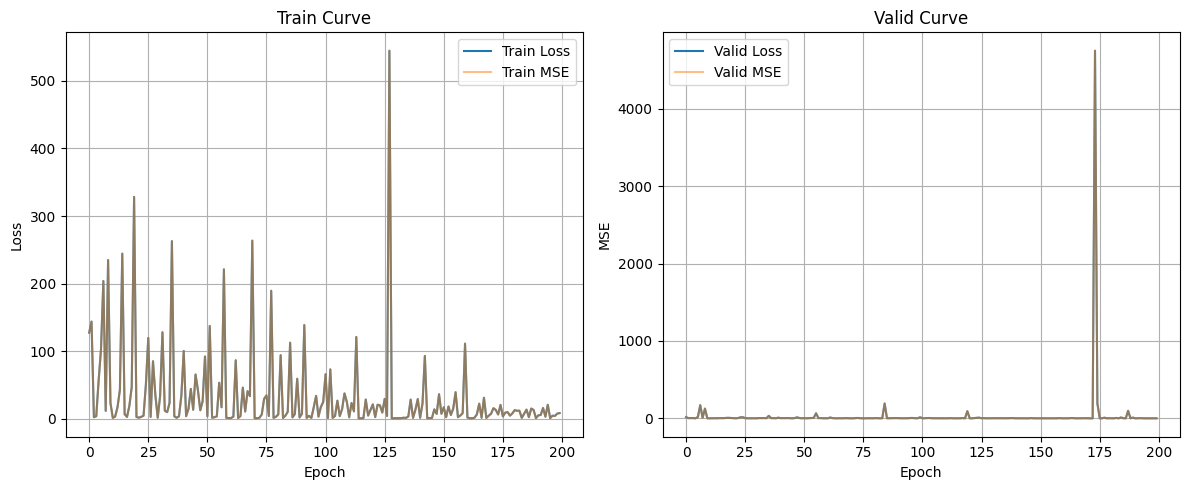

In [11]:
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_mse = history.history['mse']
val_mse = history.history['val_mse']

# 创建 1 行 2 列的子图
fig, axes = plt.subplots (nrows=1, ncols=2, figsize=(12, 5))

axes[0].plot (train_loss, label='Train Loss')
axes[0].plot (train_mse, label='Train MSE', alpha=0.5)
axes[0].set_title ('Train Curve')
axes[0].set_xlabel ('Epoch')
axes[0].set_ylabel ('Loss')
axes[0].legend ()
axes[0].grid (True)

axes[1].plot (val_loss, label='Valid Loss')
axes[1].plot (val_mse, label='Valid MSE', alpha=0.5)
axes[1].set_title ('Valid Curve')
axes[1].set_xlabel ('Epoch')
axes[1].set_ylabel ('MSE')
axes[1].legend ()
axes[1].grid (True)

plt.tight_layout ()

plt.show ()

***They are fitting*** in my opinion. Train loss looks varies a lot, but the valid loss looks stable.

# 2. Binary classification DNN [17 marks]

Consider the [Portuguese Bank Marketing Data Set](https://www.kaggle.com/yufengsui/portuguese-bank-marketing-data-set?select=bank_cleaned.csv) available at Kaggle. Download the `bank_cleaned.csv` file or from [Canvas](https://canvas.uw.edu/files/106328167/download?download_frd=1). Here we want to predict the success or failure of a bank marketing campaign using phone calls to promote a term deposit product. The target variable is `response_binary`.

The following code preprocesses the data. The day and month have been converted into cyclical features(1st day of the month has equal distance to the 2nd and the 31st).

In [12]:
df = pd.read_csv ("datasets_HW4/bank_cleaned-3.csv")

month_dict = {"jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
              "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12}
day_rad = (df["day"] - 1) * (2 * np.pi / 31)
month_rad = (df["month"].replace (month_dict) - 1) * (2 * np.pi / 12)
df["day_sin"] = np.sin (day_rad)
df["day_cos"] = np.cos (day_rad)
df["month_sin"] = np.sin (month_rad)
df["month_cos"] = np.cos (month_rad)
df.drop (columns=["Unnamed: 0", "month", "day", "response"], axis=1, inplace=True)
df.head ()

/var/folders/p5/gv35v2wx4m7fndc0tw1bvpwm0000gn/T/ipykernel_710/233110352.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  month_rad = (df["month"].replace (month_dict) - 1) * (2 * np.pi / 12)


,age,job,marital,education,default,balance,housing,loan,duration,campaign,pdays,previous,poutcome,response_binary,day_sin,day_cos,month_sin,month_cos
0,58,management,married,tertiary,no,2143,yes,no,4.35,1,-1,0,unknown,0,0.724793,0.688967,0.866025,-0.5
1,44,technician,single,secondary,no,29,yes,no,2.52,1,-1,0,unknown,0,0.724793,0.688967,0.866025,-0.5
2,33,entrepreneur,married,secondary,no,2,yes,yes,1.27,1,-1,0,unknown,0,0.724793,0.688967,0.866025,-0.5
3,35,management,married,tertiary,no,231,yes,no,2.32,1,-1,0,unknown,0,0.724793,0.688967,0.866025,-0.5
4,28,management,single,tertiary,no,447,yes,yes,3.62,1,-1,0,unknown,0,0.724793,0.688967,0.866025,-0.5


In [13]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

train_set_tmp, test_set = train_test_split (df, test_size=0.2, random_state=42)
train_set, valid_set = train_test_split (train_set_tmp, test_size=0.2, random_state=42)

X_train_raw = train_set.drop ("response_binary", axis=1).copy ()
y_train = train_set["response_binary"].copy ()
X_valid_raw = valid_set.drop ("response_binary", axis=1).copy ()
y_valid = valid_set["response_binary"].copy ()
X_test_raw = test_set.drop ("response_binary", axis=1).copy ()
y_test = test_set["response_binary"].copy ()

num_attribs = list (X_train_raw._get_numeric_data ().columns)
cat_attribs = list (set (X_train_raw.columns) - set (num_attribs))

cat_attribs_ord = ['default', 'housing', 'loan']
cat_attribs_hot = ['job', 'marital', 'education', 'poutcome']

full_pipeline = ColumnTransformer ([
    ("num", StandardScaler (), num_attribs),
    ("cat_hot", OneHotEncoder (), cat_attribs_hot),
    ("cat_ord", OrdinalEncoder (categories=[['no', 'yes'], ['no', 'yes'], ['no', 'yes']]), cat_attribs_ord)
])

X_train = full_pipeline.fit_transform (X_train_raw)
X_valid = full_pipeline.transform (X_valid_raw)
X_test = full_pipeline.transform (X_test_raw)

## (a) [4 marks]

In the next part you will build and fit a DNN with 4 hidden layers of 100 neurons each. Use the following specifications:

(i) He initialization and the Swish activation function.

(ii) The output layer has 1 neuron with sigmoid activation.

(iii) Compile with `loss="binary_crossentropy"` and  `metrics=["AUC"]`.

Explain why the choices (i), (ii), and (iii) are justified.

Also, state the proportion of sucesses in the training data.

**[Add your solution here]**

In [14]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import HeNormal

# 模型构建
model = Sequential ([
    Input (shape=(X_train.shape[1],)),  # 明确声明输入
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dense (1, activation='sigmoid')
])

(i) He initialization and Swish activation function keeps the training stable.
(ii) Output layer has 1 neuron with sigmoid is the standard approach in binary classification.
(iii) loss and metric combination is optimal for imbalanced labels.

Calculate the mean of y_train can state the proportion of success
```python
proportion_successes = y_train.mean()
print(f"Proportion of successes (positive class): {proportion_successes:.4f}")
```

## (b) [3 marks]

Train the model in (a) for 30 epochs and use exponential scheduling using the function below (`lr0=0.01`, `s=20`) and the NAG optimizer with `momentum=0.9`. Use a learning curve to comment on whether it is overfitting.

At the start of fitting your model, run `reset_session()` given by the following code.

In [15]:
def reset_session (seed=42):
    tf.random.set_seed (seed)
    np.random.seed (seed)
    tf.keras.backend.clear_session ()


def exponential_decay (lr0, s):
    return lambda epoch: lr0 * 0.1 ** (epoch / s)

**[Add your solution here]**

In [16]:
lr_schedule = tf.keras.callbacks.LearningRateScheduler (exponential_decay (lr0=0.01, s=20))
optimizer = tf.keras.optimizers.SGD (momentum=0.9, nesterov=True)

In [17]:
# 编译模型
model.compile (
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC (name='AUC')]
)

# 打印模型结构
model.summary ()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 100)            │         3,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,901 (132.43 KB)

 Trainable params: 33,901 (132.43 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
reset_session ()

history = model.fit (
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[lr_schedule],
    verbose=1
)

Epoch 1/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 643us/step - AUC: 0.8069 - loss: 0.2918 - val_AUC: 0.8965 - val_loss: 0.2296 - learning_rate: 0.0100
Epoch 2/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - AUC: 0.9012 - loss: 0.2275 - val_AUC: 0.9013 - val_loss: 0.2268 - learning_rate: 0.0089
Epoch 3/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step - AUC: 0.9090 - loss: 0.2210 - val_AUC: 0.9035 - val_loss: 0.2258 - learning_rate: 0.0079
Epoch 4/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - AUC: 0.9137 - loss: 0.2164 - val_AUC: 0.9049 - val_loss: 0.2253 - learning_rate: 0.0071
Epoch 5/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/step - AUC: 0.9172 - loss: 0.2128 - val_AUC: 0.9062 - val_loss: 0.2251 - learning_rate: 0.0063
Epoch 6/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step - AUC: 0.9201 - loss: 0.2097 - val_AUC: 0.9077 - val_loss: 0.2248 - learning_rate: 0.0056
Epoch 7/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step - AUC: 0.9224 - loss: 0.2069 - val_AUC: 0.9082 - val_loss: 0.2245 - learning_rate:

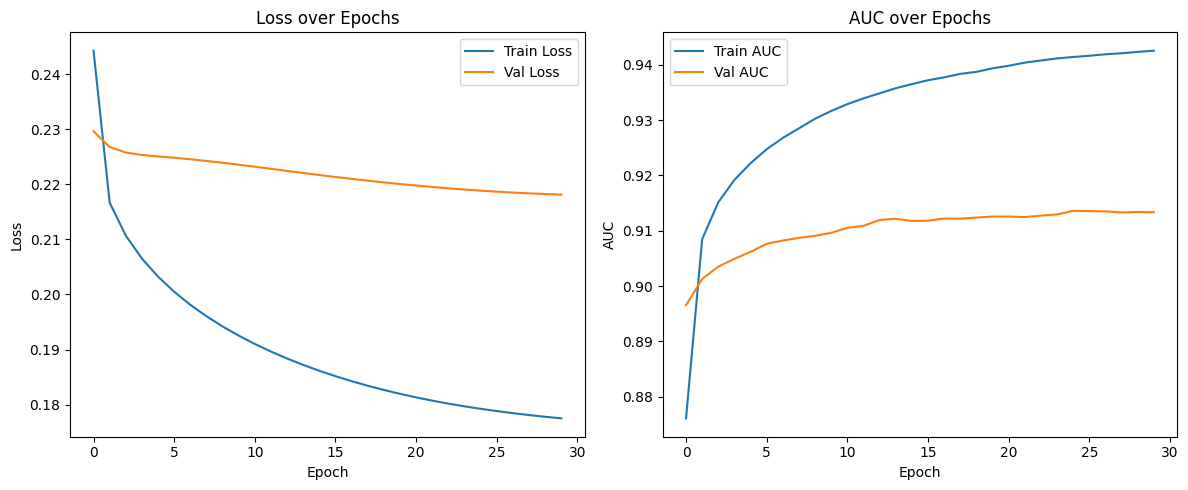

best auc: 0.9136155247688293


In [32]:
def plot_learning_curves (history):
    plt.figure (figsize=(12, 5))

    # Loss
    plt.subplot (1, 2, 1)
    plt.plot (history.history['loss'], label='Train Loss')
    plt.plot (history.history['val_loss'], label='Val Loss')
    plt.xlabel ('Epoch')
    plt.ylabel ('Loss')
    plt.title ('Loss over Epochs')
    plt.legend ()

    # AUC
    plt.subplot (1, 2, 2)
    plt.plot (history.history['AUC'], label='Train AUC')
    plt.plot (history.history['val_AUC'], label='Val AUC')
    plt.xlabel ('Epoch')
    plt.ylabel ('AUC')
    plt.title ('AUC over Epochs')
    plt.legend ()

    plt.tight_layout ()
    plt.show ()


plot_learning_curves (history)

print (f'best auc: {max (history.history['val_AUC'])}')

It seems fitting to me, valid loss gradually decrease over epochs. The AUC shows similar trend by going up on its score over epochs.

## (c) [8 marks]

Fit separate models using the same specification as in (b) but with the following regularization techniques:

(i) batch normalization,

(ii) early stopping based on validation AUC with `patience=10` (look at the documentation and note the `mode` argument).

(iii) $\ell_2$ regularization with `l2=0.0002`,

(iv) dropout with probability 0.02,

(v) $\ell_2$ regularization and early stopping both as above,

(vi) batch normalization and dropout both as above.

At the start of each one of the above models, run `reset_session()`.

The performance measure is validation AUC. State this for the model in (b), and for each of the models here comment on whether it is better than the model in (b).

**[Add your solution here]**

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
import tensorflow as tf
import numpy as np


In [21]:
lr_schedule = LearningRateScheduler (exponential_decay (0.01, 20))
optimizer = tf.keras.optimizers.SGD (learning_rate=0.01, momentum=0.9, nesterov=True)
early_stop = EarlyStopping (monitor='val_AUC', patience=10, mode='max', restore_best_weights=True)

# === 1. Batch Normalization ===
reset_session ()
model_bn = Sequential ([
    Input (shape=(X_train.shape[1],)),
    BatchNormalization (),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    BatchNormalization (),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    BatchNormalization (),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    BatchNormalization (),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dense (1, activation='sigmoid')
])
model_bn.compile (optimizer=optimizer, loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC (name='AUC')])
model_bn.summary ()
history_bn = model_bn.fit (X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, callbacks=[lr_schedule])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 34)             │           136 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         3,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,237 (137.64 KB)

 Trainable params: 34,569 (135.04 KB)

 Non-trainable params: 668 (2.61 KB)

Epoch 1/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - AUC: 0.7983 - loss: 0.3082 - val_AUC: 0.8793 - val_loss: 0.2490 - learning_rate: 0.0100
Epoch 2/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - AUC: 0.8963 - loss: 0.2339 - val_AUC: 0.8816 - val_loss: 0.2512 - learning_rate: 0.0089
Epoch 3/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step - AUC: 0.9147 - loss: 0.2153 - val_AUC: 0.8785 - val_loss: 0.2579 - learning_rate: 0.0079
Epoch 4/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step - AUC: 0.9292 - loss: 0.1988 - val_AUC: 0.8737 - val_loss: 0.2684 - learning_rate: 0.0071
Epoch 5/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - AUC: 0.9416 - loss: 0.1825 - val_AUC: 0.8669 - val_loss: 0.2827 - learning_rate: 0.0063
Epoch 6/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - AUC: 0.9529 - loss: 0.1657 - val_AUC: 0.8580 - val_loss: 0.3017 - learning_rate: 0.0056
Epoch 7/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - AUC: 0.9628 - loss: 0.1486 - val_AUC: 0.8482 - val_loss: 0.3249 - learning_rate:

In [22]:
# === 2. Early Stopping Only ===
lr_schedule = LearningRateScheduler (exponential_decay (0.01, 20))
optimizer = tf.keras.optimizers.SGD (learning_rate=0.01, momentum=0.9, nesterov=True)
early_stop = EarlyStopping (monitor='val_AUC', patience=10, mode='max', restore_best_weights=True)

reset_session ()
model_es = Sequential ([
    Input (shape=(X_train.shape[1],)),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dense (1, activation='sigmoid')
])
model_es.compile (optimizer=optimizer, loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC (name='AUC')])
model_es.summary ()
history_es = model_es.fit (X_train, y_train, epochs=30, batch_size=32, validation_split=0.2,
                           callbacks=[lr_schedule, early_stop])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         3,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,901 (132.43 KB)

 Trainable params: 33,901 (132.43 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 671us/step - AUC: 0.8273 - loss: 0.2852 - val_AUC: 0.8953 - val_loss: 0.2315 - learning_rate: 0.0100
Epoch 2/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step - AUC: 0.8979 - loss: 0.2317 - val_AUC: 0.9001 - val_loss: 0.2280 - learning_rate: 0.0089
Epoch 3/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step - AUC: 0.9048 - loss: 0.2250 - val_AUC: 0.9018 - val_loss: 0.2260 - learning_rate: 0.0079
Epoch 4/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step - AUC: 0.9091 - loss: 0.2205 - val_AUC: 0.9036 - val_loss: 0.2244 - learning_rate: 0.0071
Epoch 5/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step - AUC: 0.9128 - loss: 0.2168 - val_AUC: 0.9055 - val_loss: 0.2231 - learning_rate: 0.0063
Epoch 6/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - AUC: 0.9158 - loss: 0.2136 - val_AUC: 0.9070 - val_loss: 0.2220 - learning_rate: 0.0056
Epoch 7/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - AUC: 0.9180 - loss: 0.2106 - val_AUC: 0.9076 - val_loss: 0.2211 - learning_rate:

In [27]:
# === 3. L2 Regularization ===
lr_schedule = LearningRateScheduler (exponential_decay (0.01, 20))
optimizer = tf.keras.optimizers.SGD (learning_rate=0.01, momentum=0.9, nesterov=True)

reset_session ()
model_l2 = Sequential ([
    Input (shape=(X_train.shape[1],)),
    Dense (100, activation='swish', kernel_initializer=HeNormal (), kernel_regularizer=regularizers.l2 (0.0002)),
    Dense (100, activation='swish', kernel_initializer=HeNormal (), kernel_regularizer=regularizers.l2 (0.0002)),
    Dense (100, activation='swish', kernel_initializer=HeNormal (), kernel_regularizer=regularizers.l2 (0.0002)),
    Dense (100, activation='swish', kernel_initializer=HeNormal (), kernel_regularizer=regularizers.l2 (0.0002)),
    Dense (1, activation='sigmoid')
])
model_l2.compile (optimizer=optimizer, loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC (name='AUC')])
history_l2 = model_l2.fit (X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, callbacks=[lr_schedule])


Epoch 1/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 695us/step - AUC: 0.8182 - loss: 0.4516 - val_AUC: 0.8890 - val_loss: 0.3929 - learning_rate: 0.0100
Epoch 2/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step - AUC: 0.8986 - loss: 0.3840 - val_AUC: 0.8958 - val_loss: 0.3822 - learning_rate: 0.0089
Epoch 3/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step - AUC: 0.9063 - loss: 0.3713 - val_AUC: 0.8996 - val_loss: 0.3740 - learning_rate: 0.0079
Epoch 4/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - AUC: 0.9109 - loss: 0.3617 - val_AUC: 0.9017 - val_loss: 0.3673 - learning_rate: 0.0071
Epoch 5/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - AUC: 0.9144 - loss: 0.3540 - val_AUC: 0.9033 - val_loss: 0.3618 - learning_rate: 0.0063
Epoch 6/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step - AUC: 0.9172 - loss: 0.3475 - val_AUC: 0.9045 - val_loss: 0.3570 - learning_rate: 0.0056
Epoch 7/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step - AUC: 0.9195 - loss: 0.3420 - val_AUC: 0.9060 - val_loss: 0.3530 - learning_rate:

In [23]:
# === 4. Dropout Only ===
lr_schedule = LearningRateScheduler (exponential_decay (0.01, 20))
optimizer = tf.keras.optimizers.SGD (learning_rate=0.01, momentum=0.9, nesterov=True)

reset_session ()
model_do = Sequential ([
    Input (shape=(X_train.shape[1],)),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dropout (0.02),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dropout (0.02),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dropout (0.02),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dropout (0.02),
    Dense (1, activation='sigmoid')
])
model_do.compile (optimizer=optimizer, loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC (name='AUC')])
history_do = model_do.fit (X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, callbacks=[lr_schedule])


Epoch 1/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 735us/step - AUC: 0.8075 - loss: 0.2949 - val_AUC: 0.8927 - val_loss: 0.2320 - learning_rate: 0.0100
Epoch 2/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - AUC: 0.8970 - loss: 0.2324 - val_AUC: 0.8983 - val_loss: 0.2290 - learning_rate: 0.0089
Epoch 3/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - AUC: 0.9032 - loss: 0.2264 - val_AUC: 0.8990 - val_loss: 0.2264 - learning_rate: 0.0079
Epoch 4/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - AUC: 0.9076 - loss: 0.2221 - val_AUC: 0.9015 - val_loss: 0.2244 - learning_rate: 0.0071
Epoch 5/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - AUC: 0.9113 - loss: 0.2194 - val_AUC: 0.9031 - val_loss: 0.2230 - learning_rate: 0.0063
Epoch 6/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 610us/step - AUC: 0.9138 - loss: 0.2163 - val_AUC: 0.9036 - val_loss: 0.2222 - learning_rate: 0.0056
Epoch 7/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - AUC: 0.9165 - loss: 0.2136 - val_AUC: 0.9037 - val_loss: 0.2233 - learning_rate:

In [24]:
# === 5. L2 + EarlyStopping ===
lr_schedule = LearningRateScheduler (exponential_decay (0.01, 20))
optimizer = tf.keras.optimizers.SGD (learning_rate=0.01, momentum=0.9, nesterov=True)
early_stop = EarlyStopping (monitor='val_AUC', patience=10, mode='max', restore_best_weights=True)

reset_session ()
model_l2es = Sequential ([
    Input (shape=(X_train.shape[1],)),
    Dense (100, activation='swish', kernel_initializer=HeNormal (), kernel_regularizer=regularizers.l2 (0.0002)),
    Dense (100, activation='swish', kernel_initializer=HeNormal (), kernel_regularizer=regularizers.l2 (0.0002)),
    Dense (100, activation='swish', kernel_initializer=HeNormal (), kernel_regularizer=regularizers.l2 (0.0002)),
    Dense (100, activation='swish', kernel_initializer=HeNormal (), kernel_regularizer=regularizers.l2 (0.0002)),
    Dense (1, activation='sigmoid')
])
model_l2es.compile (optimizer=optimizer, loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC (name='AUC')])
history_l2es = model_l2es.fit (X_train, y_train, epochs=30, batch_size=32, validation_split=0.2,
                               callbacks=[lr_schedule, early_stop])


Epoch 1/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 678us/step - AUC: 0.8198 - loss: 0.4430 - val_AUC: 0.9000 - val_loss: 0.3802 - learning_rate: 0.0100
Epoch 2/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 532us/step - AUC: 0.9034 - loss: 0.3787 - val_AUC: 0.9041 - val_loss: 0.3700 - learning_rate: 0.0089
Epoch 3/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 532us/step - AUC: 0.9092 - loss: 0.3666 - val_AUC: 0.9061 - val_loss: 0.3629 - learning_rate: 0.0079
Epoch 4/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step - AUC: 0.9128 - loss: 0.3577 - val_AUC: 0.9076 - val_loss: 0.3573 - learning_rate: 0.0071
Epoch 5/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - AUC: 0.9152 - loss: 0.3506 - val_AUC: 0.9085 - val_loss: 0.3526 - learning_rate: 0.0063
Epoch 6/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step - AUC: 0.9171 - loss: 0.3447 - val_AUC: 0.9086 - val_loss: 0.3487 - learning_rate: 0.0056
Epoch 7/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step - AUC: 0.9188 - loss: 0.3397 - val_AUC: 0.9086 - val_loss: 0.3453 - learning_rate:

In [25]:
# === 6. BatchNorm + Dropout ===
lr_schedule = LearningRateScheduler (exponential_decay (0.01, 20))
optimizer = tf.keras.optimizers.SGD (learning_rate=0.01, momentum=0.9, nesterov=True)

reset_session ()
model_bndo = Sequential ([
    Input (shape=(X_train.shape[1],)),
    BatchNormalization (),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dropout (0.02),
    BatchNormalization (),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dropout (0.02),
    BatchNormalization (),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dropout (0.02),
    BatchNormalization (),
    Dense (100, activation='swish', kernel_initializer=HeNormal ()),
    Dropout (0.02),
    Dense (1, activation='sigmoid')
])
model_bndo.compile (optimizer=optimizer, loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC (name='AUC')])
history_bndo = model_bndo.fit (X_train, y_train, epochs=30, batch_size=32, validation_split=0.2,
                               callbacks=[lr_schedule])

Epoch 1/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 879us/step - AUC: 0.7942 - loss: 0.3211 - val_AUC: 0.8732 - val_loss: 0.2551 - learning_rate: 0.0100
Epoch 2/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step - AUC: 0.8870 - loss: 0.2417 - val_AUC: 0.8760 - val_loss: 0.2560 - learning_rate: 0.0089
Epoch 3/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step - AUC: 0.8992 - loss: 0.2295 - val_AUC: 0.8768 - val_loss: 0.2564 - learning_rate: 0.0079
Epoch 4/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step - AUC: 0.9139 - loss: 0.2160 - val_AUC: 0.8772 - val_loss: 0.2586 - learning_rate: 0.0071
Epoch 5/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step - AUC: 0.9218 - loss: 0.2072 - val_AUC: 0.8724 - val_loss: 0.2672 - learning_rate: 0.0063
Epoch 6/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step - AUC: 0.9291 - loss: 0.1988 - val_AUC: 0.8668 - val_loss: 0.2743 - learning_rate: 0.0056
Epoch 7/30
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 731us/step - AUC: 0.9353 - loss: 0.1898 - val_AUC: 0.8671 - val_loss: 0.2812 - learning_rate:

In [28]:
print ("BN AUC:", max (history_bn.history['val_AUC']))
print ("EarlyStopping AUC:", max (history_es.history['val_AUC']))
print ("L2 AUC:", max (history_l2.history['val_AUC']))
print ("Dropout AUC:", max (history_do.history['val_AUC']))
print ("L2+EarlyStopping AUC:", max (history_l2es.history['val_AUC']))
print ("BN+Dropout AUC:", max (history_bndo.history['val_AUC']))

BN AUC: 0.8815754055976868
EarlyStopping AUC: 0.9119134545326233
L2 AUC: 0.9139866232872009
Dropout AUC: 0.9123074412345886
L2+EarlyStopping AUC: 0.9143059253692627
BN+Dropout AUC: 0.8772013783454895


## (d) [1 mark]

For the dropout model in (c)(iv) determine whether or not it is overfitting less than the model in (b).

**[Add your solution here]**

Both have really similar AUC scores, but the dropout model seems performing worse than the model in part b.

## (e) [1 mark]

Of the models in (b) and (c), one would now choose the best model according to the performance metric (validation AUC) to evaluate on the test set. But instead, evaluate the model in (c)(v) on the test set in terms of the AUC and confusion matrix (regardless of whether it is the best model given your results).

**[Add your solution here]**

In [34]:
# model from part b
loss_b, auc_b = model.evaluate (X_test, y_test, verbose=1)

256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - AUC: 0.9196 - loss: 0.2181


In [35]:
# model from part c (v)
loss_bv, auc_bv = model_l2es.evaluate (X_test, y_test, verbose=1)

256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 380us/step - AUC: 0.9222 - loss: 0.3163


In [37]:
from sklearn.metrics import confusion_matrix

y_pred = (model_l2es.predict (X_test) >= 0.5)
cm = confusion_matrix (y_test, y_pred)
print ("Confusion matrix:\n", cm)

256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 218us/step
Confusion matrix:
 [[6932  234]
 [ 543  460]]


Based on the higher AUC on the test set (0.9222 vs 0.9196), the model from part (c)(v) is selected as the better model, as AUC is the primary metric for evaluation.

# 3. Time series using machine learning [14 marks]

Obtain daily values of the [Japan/U.S. Foreign Exchange Rate (DEXJPUS)](https://fred.stlouisfed.org/series/DEXJPUS) starting from Jan 1, 1990, to Jan 1, 2023, from FRED. This can be obtained using the code below or you can download the data as a csv file from [Canvas](https://canvas.uw.edu/files/106328118/download?download_frd=1).

In [165]:
import pandas as pd
import pandas_datareader as pdr
from datetime import datetime

data = pdr.get_data_fred ('DEXJPUS', datetime (1990, 1, 1), datetime (2023, 1, 1))

## (a) [2 marks]

Create a training set (before 2010), a validation set (Jan 2010 to Dec 2015), and a test set (the rest of the data). Turn the time series data into a supervised learning dataset where the features are the value of the exchange rate in the last 10 days inclusive of the current day, and the target is the value of the exchange rate in the next day.

**[Add your solution here]**

In [166]:
def create_sequences (data, seq_len):
    X = []
    y = []
    for i in range (len (data) - seq_len):
        X.append (data.iloc[i:i + seq_len])
        y.append (data.iloc[i + seq_len])
    return np.array (X), np.array (y)

In [167]:
# 线性插值
data['DEXJPUS'] = data['DEXJPUS'].interpolate (method='linear', limit_direction='both')

# 用mask 分类数据
mask_train = data.index < datetime (2010, 1, 1)
mask_val = (data.index >= datetime (2010, 1, 1)) & (data.index < datetime (2016, 1, 1))
mask_test = data.index >= datetime (2016, 1, 1)
data_train = data[mask_train]
data_val = data[mask_val]
data_test = data[mask_test]

In [168]:
X_train, y_train = create_sequences (data_train, seq_len=10)
X_val, y_val = create_sequences (data_val, seq_len=10)
X_test, y_test = create_sequences (data_test, seq_len=10)

## (b) [3 marks]

Fit a random forest regressor to predict the value of the exchange rate in the next day. Using the test set, report the mean squared error and the accuracy for the movement direction.

Hint: You can calculate the accuracy of the movement direction by determining what the actual movement direction is and comparing it to the movement direction corresponding to the predicted value of the exchange rate. For instance, the movement direction of the test set `X_test` and `y_test` where a strictly up movement is `True` can be computed as follows.

In [177]:
movement_test = X_test[:, -1, 0] < y_test.ravel ()

**[Add your solution here]**

In [178]:
from sklearn.ensemble import RandomForestRegressor

# flatten X
X_train_flatten = X_train.reshape (X_train.shape[0], -1)
X_test_flatten = X_test.reshape (X_test.shape[0], -1)

rfr = RandomForestRegressor (n_estimators=100, max_depth=5, random_state=42)
rfr.fit (X_train_flatten, y_train)
r2_rfr = rfr.score (X_test_flatten, y_test)

/Users/ziwenchen/PycharmProjects/LLM/.venv/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [180]:
from sklearn.metrics import accuracy_score, mean_squared_error

y_pred_rfr = rfr.predict (X_test_flatten)
movement_pred_rfr = X_test[:, -1, 0] < y_pred_rfr.ravel ()

movement_acc_rfr = accuracy_score (movement_test, movement_pred_rfr)
mse_rfr = mean_squared_error (y_test, y_pred_rfr)

print (f"movement accuracy random forest regressor: {movement_acc_rfr * 100:.2f}%")
print (f"MSE random forest regressor: {mse_rfr}")

movement accuracy random forest regressor: 50.17%
MSE random forest regressor: 0.5096548293939561


## (c) [4 marks]

Repeat (b), but now fit a deep RNN with 2 recurrent layers of 20 and 20 neurons, and an output layer which is 1 dense neuron. Use 100 epochs and the Nadam optimizer. Comment on the result and the learning curve (the validation set is used for the learning curve).

**[Add your solution here]**

In [181]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Nadam

# 模型结构
reset_session ()
model_rnn = Sequential ([
    Input (shape=(X_train.shape[1], X_train.shape[2])),
    SimpleRNN (20, return_sequences=True),
    SimpleRNN (20),
    Dense (1)
])

# 编译模型
model_rnn.compile (optimizer=Nadam (), loss='mse')

model_rnn.summary ()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10, 20)         │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [182]:
# 训练模型（记录训练和验证损失）
history = model_rnn.fit (
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12823.2490 - val_loss: 7861.1240
Epoch 2/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 11505.5508 - val_loss: 7235.9351
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10757.3848 - val_loss: 6672.9712
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10068.6162 - val_loss: 6148.8169
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9420.3740 - val_loss: 5657.4702
Epoch 6/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8806.7764 - val_loss: 5195.8442
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8224.6572 - val_loss: 4761.8994
Epoch 8/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7671.8867 - val_loss: 4354.0845
Epoch 9/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7146.8330 - val_loss: 3971.1289
Epoch 10/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6648.1636 - val_loss: 3611.9312
Epoch 11/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 617

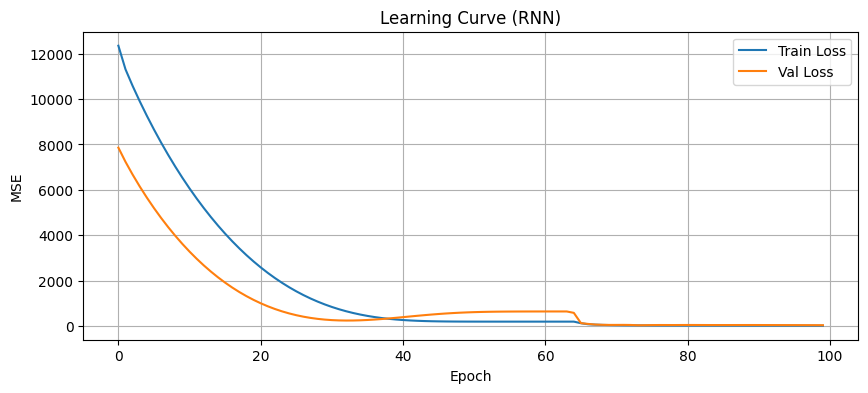

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
movement accuracy rnn: 50.39%
MSE rnn: 3.2879397794026337


In [183]:
# 画出学习曲线
plt.figure (figsize=(10, 4))
plt.plot (history.history['loss'], label='Train Loss')
plt.plot (history.history['val_loss'], label='Val Loss')
plt.xlabel ('Epoch')
plt.ylabel ('MSE')
plt.title ('Learning Curve (RNN)')
plt.legend ()
plt.grid (True)
plt.show ()

y_pred_rnn = model_rnn.predict (X_test)
mse_rnn = mean_squared_error (y_test, y_pred_rnn)
movement_pred_rnn = X_test[:, -1, 0] < y_pred_rnn.ravel ()
movement_acc_rnn = accuracy_score (movement_test, movement_pred_rnn)

print (f"movement accuracy rnn: {movement_acc_rnn * 100:.2f}%")
print (f"MSE rnn: {mse_rnn}")

## (d) [5 marks]

Create a supervised learning dataset suitable for predicting 3 days ahead instead of 1 day ahead. Adjust the deep RNN in (c) so that it predicts 3 days ahead. Use 100 epochs and the Nadam optimizer. Using the test set, report the mean squared error and the accuracy for the movement direction for each of the 3 days ahead predictions.  Comment on the result and the learning curve.

**[Add your solution here]**

In [184]:
def create_sequences_forward (data, seq_len, forward=0):
    X = []
    y = []
    for i in range (len (data) - seq_len - forward):
        X.append (data.iloc[i:i + seq_len])
        y.append (data.iloc[i + seq_len:i + seq_len + forward])
    return np.array (X), np.array (y)

In [185]:
X_train, y_train = create_sequences_forward (data_train, seq_len=10, forward=3)
X_val, y_val = create_sequences_forward (data_val, seq_len=10, forward=3)
X_test, y_test = create_sequences_forward (data_test, seq_len=10, forward=3)

In [186]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Nadam

# 模型结构
reset_session ()
model_rnn_3ahead = Sequential ([
    Input (shape=(X_train.shape[1], X_train.shape[2])),
    SimpleRNN (20, return_sequences=True),
    SimpleRNN (20),
    Dense (3)
])

# 编译模型
model_rnn_3ahead.compile (optimizer=Nadam (), loss='mse')

model_rnn_3ahead.summary ()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10, 20)         │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323 (5.17 KB)

 Trainable params: 1,323 (5.17 KB)

 Non-trainable params: 0 (0.00 B)

In [187]:
history_3ahead_rnn = model_rnn_3ahead.fit (
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13088.7705 - val_loss: 8377.2129
Epoch 2/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 12125.1514 - val_loss: 7749.2534
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 11372.1807 - val_loss: 7171.2202
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10669.1670 - val_loss: 6629.4893
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10004.0977 - val_loss: 6119.4761
Epoch 6/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9372.4365 - val_loss: 5638.6396
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8771.5771 - val_loss: 5185.2100
Epoch 8/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8199.6777 - val_loss: 4757.7939
Epoch 9/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7655.2754 - val_loss: 4355.2197
Epoch 10/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7137.1533 - val_loss: 3976.4609
Epoch 11/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 66

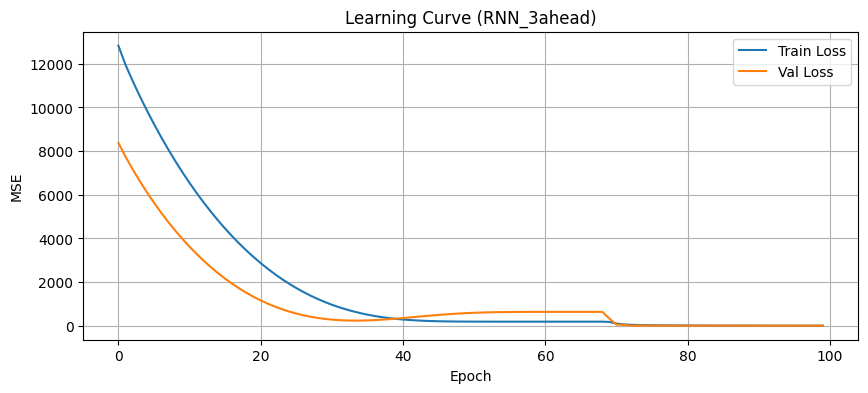

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step
movement accuracy rnn_3ahead day 1: 49.31%
movement accuracy rnn_3ahead day 2: 49.97%
movement accuracy rnn_3ahead day 3: 50.74%
MSE rnn_3ahead day 1: 0.6257720795859847
MSE rnn_3ahead day 2: 1.0406098208869934
MSE rnn_3ahead day 3: 1.4299839923206321


In [189]:
# 画出学习曲线
plt.figure (figsize=(10, 4))
plt.plot (history_3ahead_rnn.history['loss'], label='Train Loss')
plt.plot (history_3ahead_rnn.history['val_loss'], label='Val Loss')
plt.xlabel ('Epoch')
plt.ylabel ('MSE')
plt.title ('Learning Curve (RNN_3ahead)')
plt.legend ()
plt.grid (True)
plt.show ()

y_test_flatten = y_test.reshape(y_test.shape[0], -1)
movement_test_day1 = X_test[:, -1, 0] < y_test_flatten[:, 0]
movement_test_day2 = X_test[:, -1, 0] < y_test_flatten[:, 1]
movement_test_day3 = X_test[:, -1, 0] < y_test_flatten[:, 2]

y_pred_rnn_3ahead = model_rnn_3ahead.predict (X_test)
mse_rnn_day1 = mean_squared_error (y_test_flatten[:,0], y_pred_rnn_3ahead[:,0])
mse_rnn_day2 = mean_squared_error (y_test_flatten[:,1], y_pred_rnn_3ahead[:,1])
mse_rnn_day3 = mean_squared_error (y_test_flatten[:,2], y_pred_rnn_3ahead[:,2])


movement_pred_rnn_day1 = X_test[:, -1, 0] < y_pred_rnn_3ahead[:, 0]
movement_pred_rnn_day2 = X_test[:, -1, 0] < y_pred_rnn_3ahead[:, 1]
movement_pred_rnn_day3 = X_test[:, -1, 0] < y_pred_rnn_3ahead[:, 2]
movement_acc_rnn_day1 = accuracy_score (movement_test_day1, movement_pred_rnn_day1)
movement_acc_rnn_day2 = accuracy_score (movement_test_day2, movement_pred_rnn_day2)
movement_acc_rnn_day3 = accuracy_score (movement_test_day3, movement_pred_rnn_day3)

print (f"movement accuracy rnn_3ahead day 1: {movement_acc_rnn_day1 * 100:.2f}%")
print (f"movement accuracy rnn_3ahead day 2: {movement_acc_rnn_day2 * 100:.2f}%")
print (f"movement accuracy rnn_3ahead day 3: {movement_acc_rnn_day3 * 100:.2f}%")
print (f"MSE rnn_3ahead day 1: {mse_rnn_day1}")
print (f"MSE rnn_3ahead day 2: {mse_rnn_day2}")
print (f"MSE rnn_3ahead day 3: {mse_rnn_day3}")

The learning curve looks reasonable. The movement accuracy for each of the 3 predicted days does not differ significantly but becoming more and more accurate. However, the increasing MSE over the predicted days indicates that prediction errors accumulate over time, implying that future values are harder to predict.